In [ ]:
# Atividade de vendas no Brasil

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload() #Só consegui fazer pelo colab, meu computador deu problema para carregar o arquivo vendas_brasil_1.csv no VS Code, mas vou arrumar isso para as próximas tarefas semanais.

Saving vendas_brasil_1.csv to vendas_brasil_1.csv


In [ ]:
## Entregável 1 NumPy

In [ ]:
df = pd.read_csv("vendas_brasil_1.csv")
print(df.columns)

Index(['data_venda', 'mes', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'preco_unitario', 'custo_unitario',
       'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete',
       'avaliacao_cliente', 'prazo_entrega_dias', 'devolucao',
       'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco'],
      dtype='object')


In [ ]:
#A. Criando arrays

preco = df["preco_unitario"].to_numpy()
custo = df["custo_unitario"].to_numpy()
quantidade = df["quantidade"].to_numpy()
desconto = df["desconto_pct"].to_numpy()
receita = df["receita_total"].to_numpy()
frete = df["frete"].to_numpy()


#B. Cálculos com operações vetorizadas

valor_bruto = preco * quantidade

valor_desconto = valor_bruto * (desconto / 100)

custo_total = custo * quantidade

lucro_estimado = receita - custo_total - frete


#C. Máscaras booleanas

media_receita = receita.mean()
acima_media = receita > media_receita
prejuizo = lucro_estimado < 0
desconto_alto = desconto > 20 #Considerando altos os descontos maiores que 20%

print("Vendas com receita acima da média:", acima_media.sum())

print("Vendas com prejuízo:", prejuizo.sum())

print("Vendas com desconto alto:", desconto_alto.sum())


#D. Agregações

print("Receita média:", receita.mean())

print("Maior receita:", receita.max())

print("Menor receita:", receita.min())

print("Lucro médio:", np.nanmean(lucro_estimado))

print("Quantidade de vendas com prejuízo:", prejuizo.sum())

Vendas com receita acima da média: 9236
Vendas com prejuízo: 5857
Vendas com desconto alto: 7037
Receita média: 1891.6881729005502
Maior receita: 58430.28
Menor receita: 3.7
Lucro médio: 482.3832357714477
Quantidade de vendas com prejuízo: 5857


In [ ]:
# A partir da análise realizada, foi possível observar que 9236 vendas apresentaram receita acima da média, enquanto 5857 apresentaram prejuízo e, como 7037 vendas tiveram desconto alto, pode-se inferir que o elevado desconto pode ter influenciado na grande quantidade de vendas sem lucro. Além disso, a receita apresentou grande variação entre as vendas, com média de aproximadamente 1891 e valores entre 3.7 e 58430.28. O lucro médio, apesar de muitas vendas terem prejuízo, é de aproximadamente 482, indicando que, de forma geral, o conjunto de vendas apresentou resultado financeiro positivo, mesmo com um número significativo de prejuízos.

In [ ]:
## Entregável 2 Pandas

In [ ]:
#A. Primeiro olhar no dataset

df.head()
df.info()
df.describe()
df.shape
df.isna().sum()

#1. Quantas linhas e colunas existem?
## Existem 37617 linhas e 21 colunas

#2. Existem dados faltantes?
## Sim, nas colunas canal_venda, vendedor, margem_pct, frete, avaliacao_cliente e prazo_entrega_dias.

#3. Quais colunas parecem numéricas?
## As colunas mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente e prazo_entrega_dias.

#4. Quais colunas parecem categóricas?
## As colunas data_venda, cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente, devolucao, entrega_no_prazo, alta_temporada e flag_outlier_preco.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

,0
data_venda,0
mes,0
cidade,0
canal_venda,50
categoria,0
produto,0
vendedor,40
fidelidade_cliente,0
preco_unitario,0
custo_unitario,0


['Rio de Janeiro' 'Manaus' 'Goiânia' 'Fortaleza' 'Belo Horizonte' 'Recife'
 'São Paulo' 'Porto Alegre' 'Salvador' 'Curitiba' 'salvador'
 'Belo Horizonte ' 'Rio de janeiro' 'Curtiba' 'Curitiba ' 'SP'
 ' Fortaleza' 'curitiba' 'RJ' 'S. Paulo' ' Salvador' 'Manaus ' 'São paulo'
 'Fortaleza ' 'Sao Paulo' 'BH' 'Rio de Janeiro ' ' Belo Horizonte'
 ' Recife' 'Slavador' 'Belo horizonte' 'Rio' ' Curitiba' ' Manaus'
 ' Goiânia' 'Recife ' 'B. Horizonte' 'Porto Alegre ' 'Rio De Janeiro'
 'São Paulo ' 'Goiânia ' ' Porto Alegre' 'Salvador ' ' Rio de Janeiro'
 ' São Paulo']


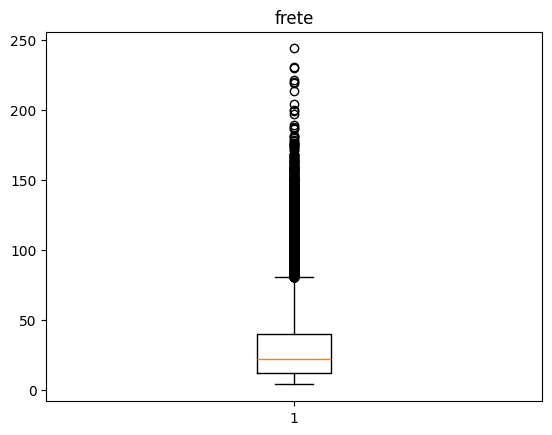

np.int64(0)

In [ ]:
#B. Limpeza e tratamento

## Convertendo a coluna 'data_venda' para datetime
df["data_venda"] = pd.to_datetime(
    df["data_venda"],
    format="mixed",
)

## Padronizando a coluna 'cidade', que tem valores escritos de formas diferentes
print(df["cidade"].unique()) # Ver se tem formatos diferentes de escrita

df["cidade"] = df["cidade"].str.strip() # Tirando os espaços
df["cidade"] = df["cidade"].str.lower() # Arrumando as letras maiúsculas

df["cidade"] = df["cidade"].replace({ #Selecionando apenas uma forma de escrever para cada cidade que aparece
    "rj": "Rio de Janeiro",
    "rio": "Rio de Janeiro",
    "rio de janeiro": "Rio de Janeiro",

    "sp": "São Paulo",
    "sao paulo": "São Paulo",
    "s. paulo": "São Paulo",
    "são paulo": "São Paulo",

    "bh": "Belo Horizonte",
    "b. horizonte": "Belo Horizonte",
    "belo horizonte": "Belo Horizonte",

    "curtiba": "Curitiba",
    "curitiba": "Curitiba",

    "slavador": "Salvador",
    "salvador": "Salvador",

    "fortaleza": "Fortaleza",
    "recife": "Recife",
    "manaus": "Manaus",
    "porto alegre": "Porto Alegre",
    "goiânia": "Goiânia"
})

df["cidade"].unique() # Verificando as mudanças feitas


## Tratando dados faltantes da coluna 'frete'
df["frete"].isna().sum()
df["frete"].dtype
df["frete"].describe()

import matplotlib.pyplot as plt
# Fazendo boxplot para analisar os outliers e decidir se é melhor usar a mediana ou a média para os valores faltantes
plt.boxplot(df["frete"].dropna())
plt.title("frete")
plt.show()

# Os valores faltantes da coluna 'frete' foram preenchidos pela mediana, pois essa medida é menos sensível a valores extremos do que a média (já que a coluna apresenta muitos outliers)
df["frete"] = df["frete"].fillna(df["frete"].median())

df["frete"].isna().sum()

In [ ]:
#C. Criação de novas colunas

## Criando coluna do ano de venda
df["ano_venda"] = df["data_venda"].dt.year

## Criando coluna do mês de venda
df["mes_venda"] = df["data_venda"].dt.month


## Criando coluna de lucro total
df["lucro_total"] = df.apply(
    lambda linha: (
        (linha["preco_unitario"] * linha["quantidade"] * (1 - linha["desconto_pct"] / 100))
        - (linha["custo_unitario"] * linha["quantidade"])
    ),
    axis=1
)

print(df.columns)

df[["ano_venda", "mes_venda", "lucro_total"]].head()

Index(['data_venda', 'mes', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'preco_unitario', 'custo_unitario',
       'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete',
       'avaliacao_cliente', 'prazo_entrega_dias', 'devolucao',
       'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco', 'ano_venda',
       'mes_venda', 'lucro_total'],
      dtype='object')


,ano_venda,mes_venda,lucro_total
0,2022,4,1391.91720
1,2023,3,256.02560
2,2022,9,198.48122
3,2022,4,621.00324
4,2022,3,0.55560


In [ ]:
#D. Filtros

##1. Quais vendas tiveram receita acima de determinado valor?
valor = 5000

filtro_receita = df[df["receita_total"] > valor]

print("Vendas com receita acima de", valor)
print(filtro_receita)

print(f"\nForam encontradas {len(filtro_receita)} vendas com receita acima de R$ {valor}.")


##2. Quais vendas tiveram devolução?
filtro_devolucao = df[df["devolucao"] == "True"]

print("Vendas com devolução:")
print(filtro_devolucao)

print(f"\nForam encontradas {len(filtro_devolucao)} vendas com devolução.")


##3. Quais vendas pertencem a uma categoria específica?
categoria = "Vestuário"

filtro_categoria = df[df["categoria"] == categoria]

print(f"Vendas da categoria {categoria}:")
print(filtro_categoria)

print(f"\nForam encontradas {len(filtro_categoria)} vendas da categoria {categoria}.")

Vendas com receita acima de 5000
      data_venda  mes          cidade  canal_venda    categoria  \
0     2022-04-13    4  Rio de Janeiro   App Mobile  Eletrônicos   
15    2022-04-10    4        Salvador  Marketplace  Eletrônicos   
20    2022-12-10   12          Recife     Site Web  Eletrônicos   
21    2023-05-07    5       São Paulo  Loja Física  Eletrônicos   
25    2022-10-04   10  Rio de Janeiro  Loja Física  Eletrônicos   
...          ...  ...             ...          ...          ...   
37524 2023-12-31   11       Fortaleza   Televendas  Eletrônicos   
37530 2023-12-31    4  Rio de Janeiro   App Mobile  Eletrônicos   
37566 2023-12-31   12        Salvador  Loja Física  Eletrônicos   
37578 2023-12-31   10          Manaus  Loja Física  Eletrônicos   
37583 2023-12-31    2          Manaus  Loja Física  Eletrônicos   

              produto       vendedor fidelidade_cliente  preco_unitario  \
0            Notebook    Bruno Souza           Diamante          739.39   
15         S

In [ ]:
#E. Agrupamentos com groupby

##1. Qual categoria teve maior receita total?
receita_categoria = df.groupby("categoria")["receita_total"].sum()

print(receita_categoria)

print(receita_categoria.idxmax())
maior_categoria = receita_categoria.idxmax()

print(f"\nA maior receita total foi em {maior_categoria}.")


##2. Qual canal de venda teve maior quantidade de vendas?
vendas_canal = df.groupby("canal_venda")["canal_venda"].count()

print(vendas_canal)

print(vendas_canal.idxmax())
maior_canal = vendas_canal.idxmax()
print(f"\nA maior quantidade de vendas foi em {maior_canal}.")


##3. Qual cidade teve maior receita?
receita_cidade = df.groupby("cidade")["receita_total"].sum()

print(receita_cidade)

print(receita_cidade.idxmax())
maior_cidade = receita_cidade.idxmax()
print(f"\nA cidade com maior receita foi {maior_cidade}.")

categoria
Alimentação     3331601.51
Eletrônicos    45017479.88
Esportes       11567480.75
Livros          4462597.93
Vestuário       6780473.93
Name: receita_total, dtype: float64
Eletrônicos

A maior receita total foi em Eletrônicos.
canal_venda
APP Mobile        29
App Mobile     11168
App mobile        28
Loja Fisica       18
Loja Física     7445
Loja fisica       13
Marketplace     5604
Site Web       11267
Site web          24
SiteWeb           31
Televendas      1861
app mobile        33
loja física       22
site web          24
Name: canal_venda, dtype: int64
Site Web

A maior quantidade de vendas foi em Site Web.
cidade
Belo Horizonte    6914747.61
Curitiba          6993175.07
Fortaleza         7242081.82
Goiânia           7178113.69
Manaus            7459161.23
Porto Alegre      7048428.17
Recife            7662241.79
Rio de Janeiro    6880176.34
Salvador          6918656.01
São Paulo         6862852.27
Name: receita_total, dtype: float64
Recife

A cidade com maior receita fo

In [ ]:
#F. Merge
regioes = pd.DataFrame({
    "cidade": [
        "Rio de Janeiro",
        "São Paulo",
        "Belo Horizonte",
        "Curitiba",
        "Salvador"
    ],
    "regiao": [
        "Sudeste",
        "Sudeste",
        "Sudeste",
        "Sul",
        "Nordeste"
    ]
})
df = df.merge(regioes, on="cidade", how="left")

receita_regiao = df.groupby("regiao")["receita_total"].sum()

print(receita_regiao)

## Por essa análise, percebe-se que a região Sudeste é a que apresenta a maior receita total dentre as regiões apresentadas, de 20657776.22 reais. Em seguida, a região Sul apresenta 6993175.07 reais de receita total, enquanto a região Nordeste 6918656.01 reais.

regiao
Nordeste     6918656.01
Sudeste     20657776.22
Sul          6993175.07
Name: receita_total, dtype: float64


In [ ]:
##Entregável 3 Seaborn

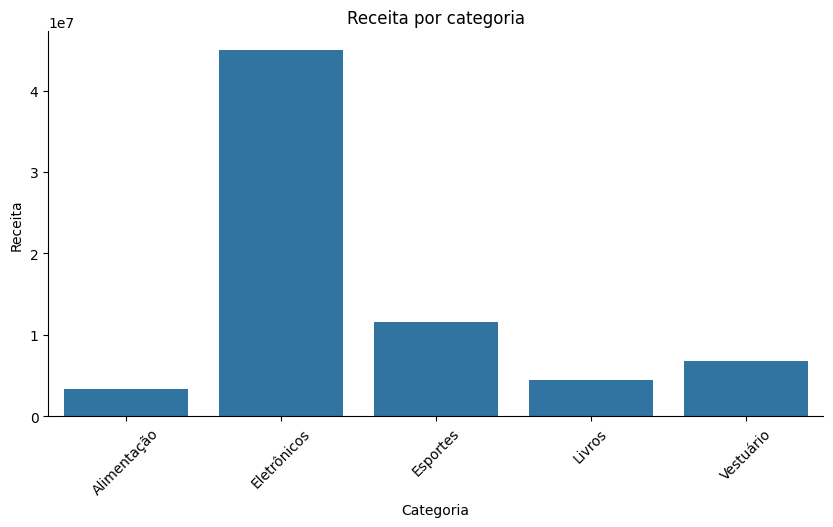

/tmp/ipykernel_7977/3609215043.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  receita_mes = df.resample("M", on="data_venda")["receita_total"].sum().reset_index()


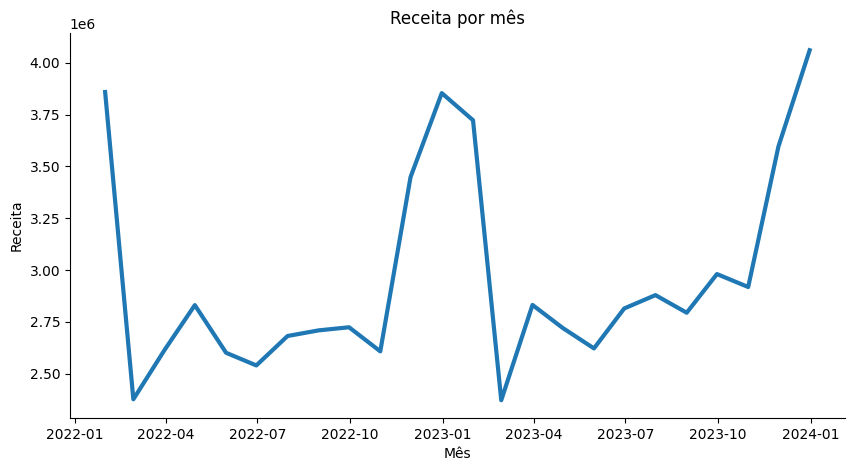

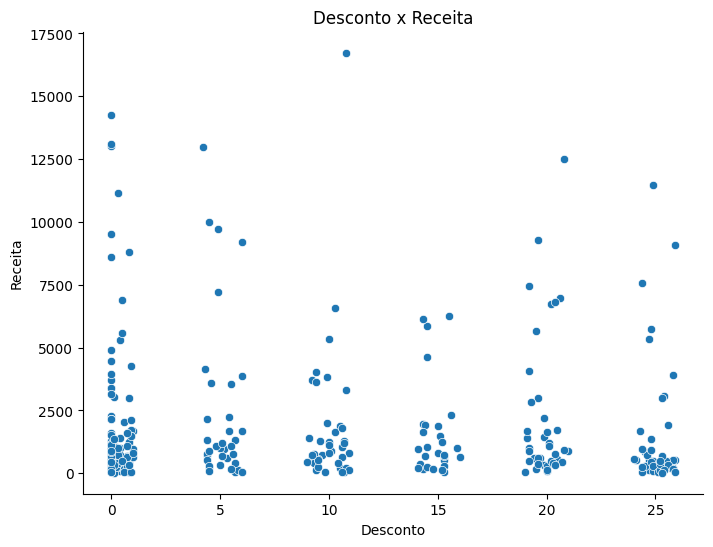

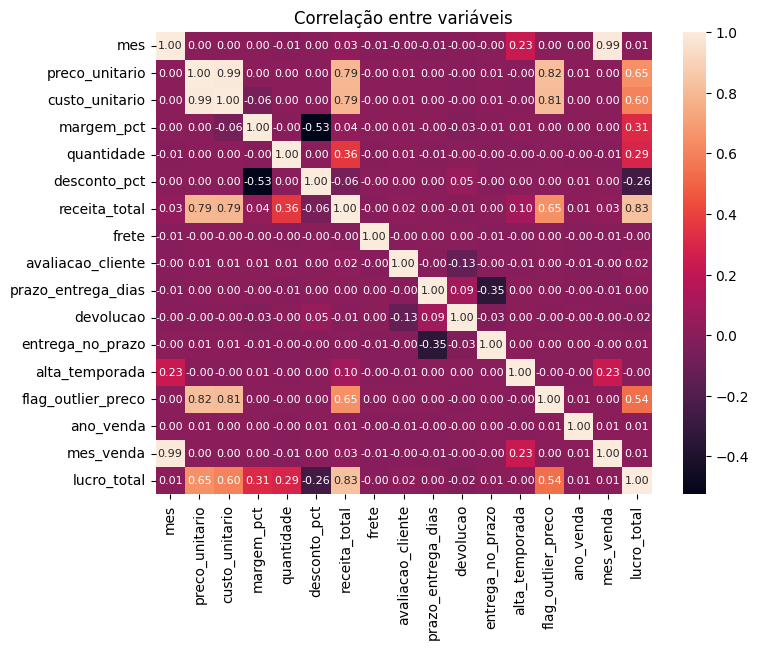

In [ ]:
#A. Gráfico de barras
plt.figure(figsize=(10,5))
receita_categoria = (
    df.groupby("categoria")["receita_total"]
      .sum()
      .reset_index()
)
sns.barplot(
    data=receita_categoria,
    x="categoria",
    y="receita_total",
    linewidth=1
)

plt.title("Receita por categoria")
plt.xlabel("Categoria")
plt.ylabel("Receita")

plt.xticks(rotation=45)

sns.despine()

plt.show()

## Pelo gráfico de barras, pode-se observar que a categoria "eletrônicos" apresenta receita maior que as demais, enquanto a categoria "Alimentação" apresenta a menor receita entre as categorias.


#B. Gráfico de linha
df["data_venda"] = pd.to_datetime(df["data_venda"])

receita_mes = df.resample("M", on="data_venda")["receita_total"].sum().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=receita_mes,
    x="data_venda",
    y="receita_total",
    linewidth=3
)

plt.title("Receita por mês")
plt.xlabel("Mês")
plt.ylabel("Receita")

sns.despine()

plt.show()

## O gráfico mostra que a receita diminui depois do início do ano. Pode-se perceer que, após janeiro de 2022, a receita diminui drasticamente, voltando a aumentar apenas em janeiro de 2023. O mesmo acontece entre janeiro de 2023 e janeiro de 2024, podendo estipular que, durante o ano, as receitas tendem a diminuir e, no início do ano, elas tendem a serem maiores.


#C. Gráfico de dispersão
amostra = df.sample(300, random_state=42)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=amostra,
    x="desconto_pct",
    y="receita_total"
)

plt.title("Desconto x Receita")
plt.xlabel("Desconto")
plt.ylabel("Receita")

sns.despine()

plt.show()

## A partir do gráfico de dispersão, percebe-se que as variáveis "desconto_pct" e "receita_total" não apresentam uma relação linear evidente, indicando que não há uma correlação forte entre elas. Além disso, é possível observar uma maior concentração de vendas com receitas relativamente baixas, enquanto poucas observações apresentam receitas muito elevadas, caracterizando possíveis outliers (valores discrepantes).


#D. Mapa de calor
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size":8}
)
plt.title("Correlação entre variáveis")

plt.show()

## O mapa de calor (heatmap) mostra que as variáveis "preco_unitario" e "custo_unitario" apresentam uma correlação positiva muito forte (0,99), indicando que produtos com maior preço unitário tendem a possuir custos unitários mais elevados. Além disso, "receita_total" e "lucro_total" também apresentam uma correlação positiva elevada, sugerindo que maiores receitas costumam estar associadas a maiores lucros. Por outro lado, a maior parte das demais variáveis apresenta correlações fracas ou próximas de zero, indicando pouca ou nenhuma relação de linearidade entre elas.